In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sympy import symbols, Matrix, pi, cos, sin, simplify, eye, solve, latex
from sympy.physics.mechanics import ReferenceFrame, dynamicsymbols, init_vprinting, express
from scipy.optimize import root

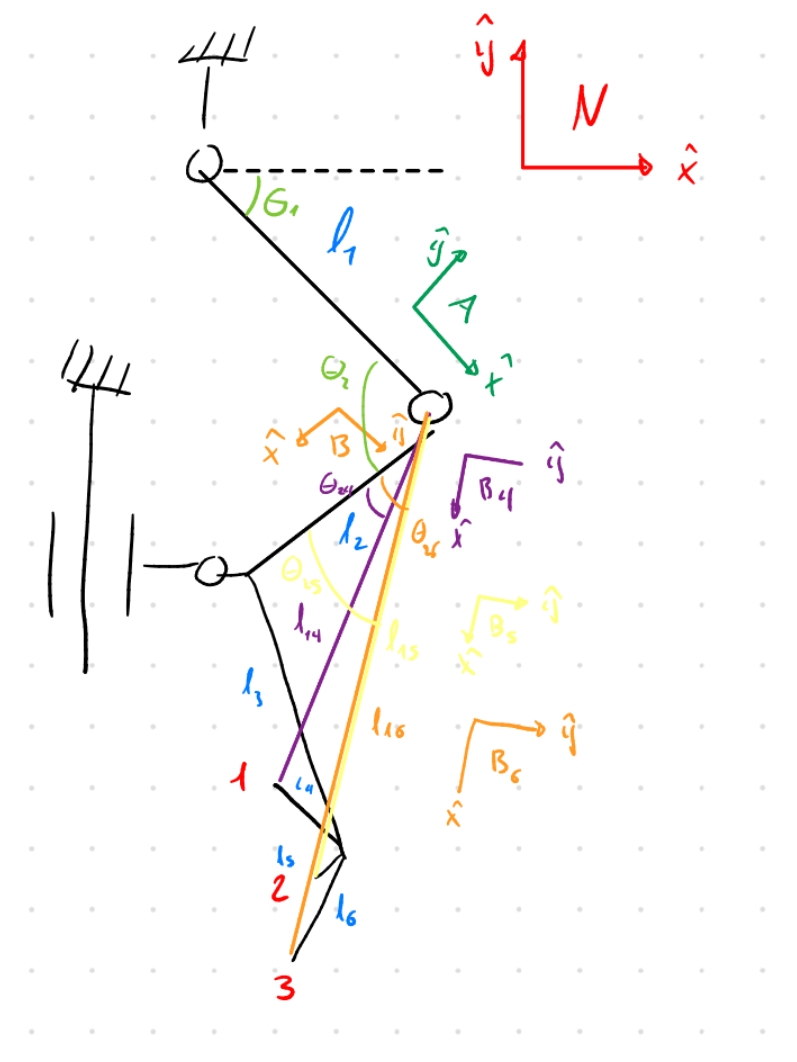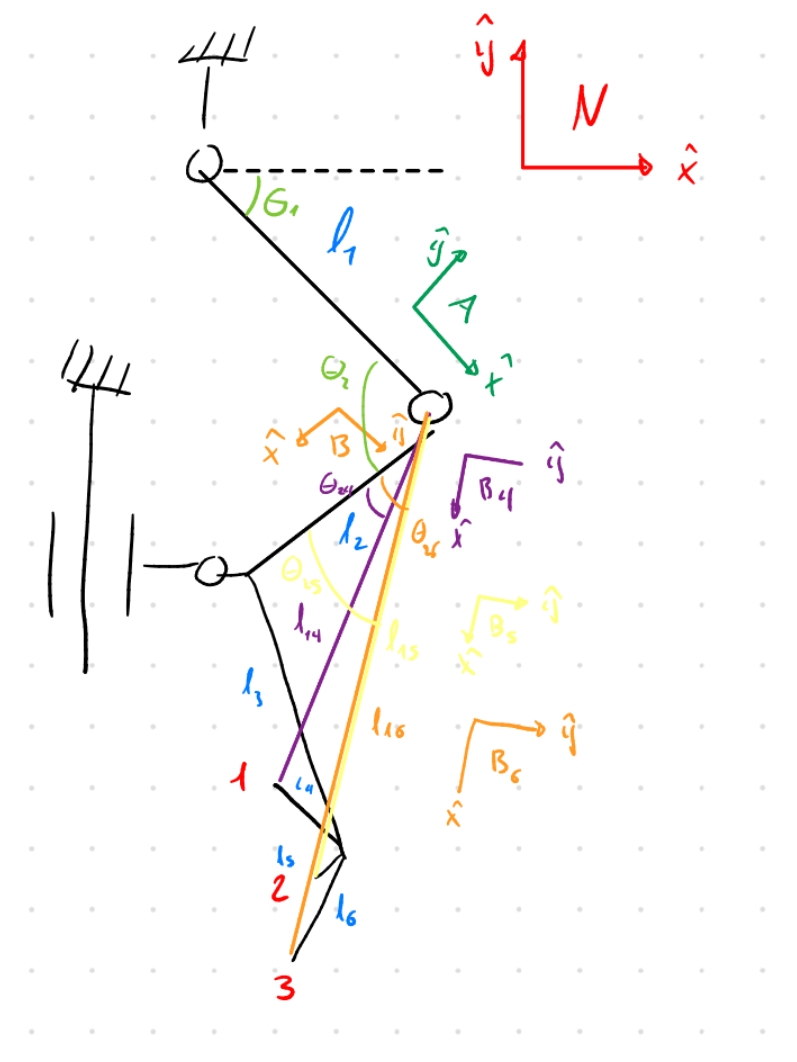

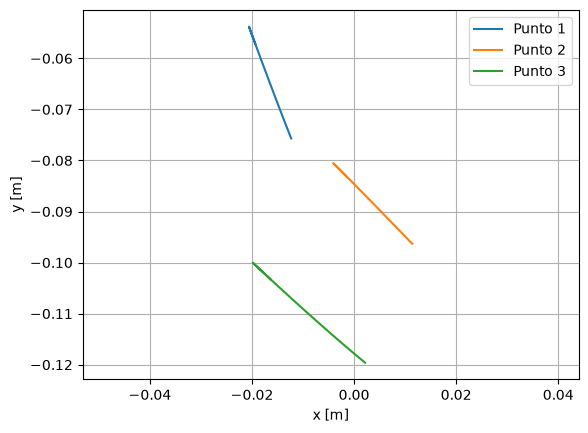

In [5]:
#MECANISMO 1
l1, l2, l1_4, l1_5, l1_6, theta2_4, theta2_5, theta2_6 = symbols(
    'l1, l2, l1_4, l1_5, l1_6, theta2_4, theta2_5, theta2_6'
)

datos = {
    l1: 0.054,
    l1_4: 0.071,
    l1_5: 0.072,
    l1_6: 0.097,
    theta2_4: np.deg2rad(20.14),
    theta2_5: np.deg2rad(45.52),
    theta2_6: np.deg2rad(46.79),
    l2: 0.0458
}


def posiciones_garra(theta1):
    lista_posiciones = []

    for valor in theta1:

        angulo = valor

        N = ReferenceFrame('N')
        A = N.orientnew('A', 'Axis', [-angulo, N.z])

        r1 = l1 * A.x

        theta2 = angulo + sp.acos((r1.dot(N.x)) / l2)

        B = A.orientnew('B', 'Axis', [sp.pi + theta2, A.z])

        B4 = B.orientnew('B4', 'Axis', [theta2_4, B.z])
        B5 = B.orientnew('B5', 'Axis', [theta2_5, B.z])
        B6 = B.orientnew('B6', 'Axis', [theta2_6, B.z])

        # Punto 1
        r1_4 = l1_4 * B4.x
        rsum1 = (r1 + r1_4).express(N).simplify().subs(datos)

        pos1 = (
            rsum1.dot(N.x).simplify(),
            rsum1.dot(N.y).simplify()
        )

        # Punto 2
        r1_5 = l1_5 * B5.x
        rsum2 = (r1 + r1_5).express(N).simplify().subs(datos)

        pos2 = (
            rsum2.dot(N.x).simplify(),
            rsum2.dot(N.y).simplify()
        )

        # Punto 3
        r1_6 = l1_6 * B6.x
        rsum3 = (r1 + r1_6).express(N).simplify().subs(datos)

        pos3 = (
            rsum3.dot(N.x).simplify(),
            rsum3.dot(N.y).simplify()
        )

        lista_posiciones.append((pos1, pos2, pos3))

    return lista_posiciones


valores_de_actuador = np.linspace(0.026, 0.046, 20)

val_theta1 = []

for actuador in valores_de_actuador:

    theta1 = sp.pi/2 - sp.acos(
        (l2**2 - l1**2 - actuador**2) / (-2*l1*actuador)
    )

    theta1 = theta1.subs(datos)
    val_theta1.append(float(theta1))

posiciones = posiciones_garra(val_theta1)

posiciones

# Separar las coordenadas de cada punto
x1 = [float(pos[0][0]) for pos in posiciones]
y1 = [float(pos[0][1]) for pos in posiciones]

x2 = [float(pos[1][0]) for pos in posiciones]
y2 = [float(pos[1][1]) for pos in posiciones]

x3 = [float(pos[2][0]) for pos in posiciones]
y3 = [float(pos[2][1]) for pos in posiciones]


# Graficar las 3 trayectorias en una sola gráfica
plt.plot(x1, y1, label='Punto 1')
plt.plot(x2, y2, label='Punto 2')
plt.plot(x3, y3, label='Punto 3')

plt.axis('equal')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.grid()
plt.legend()
plt.show()

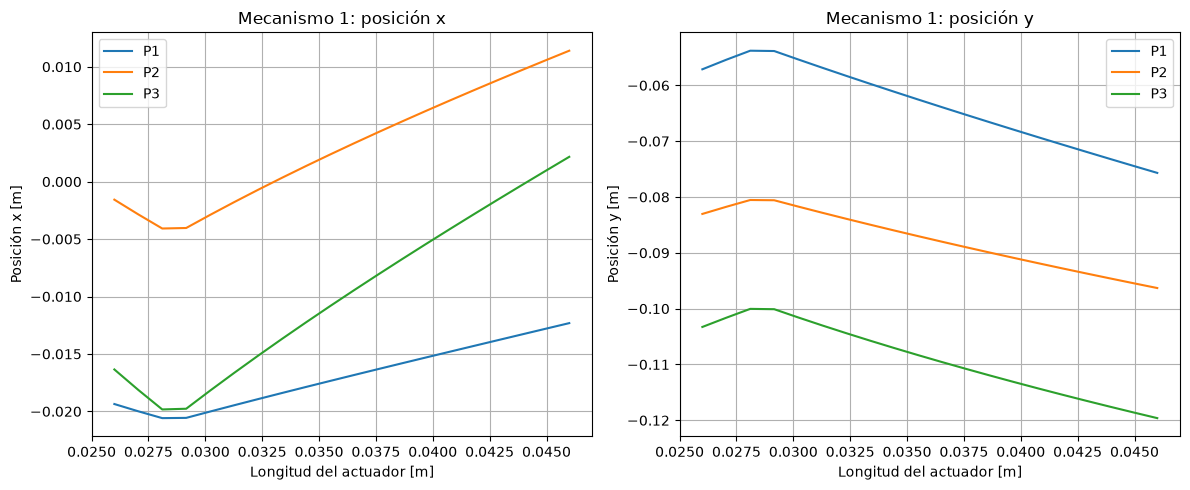

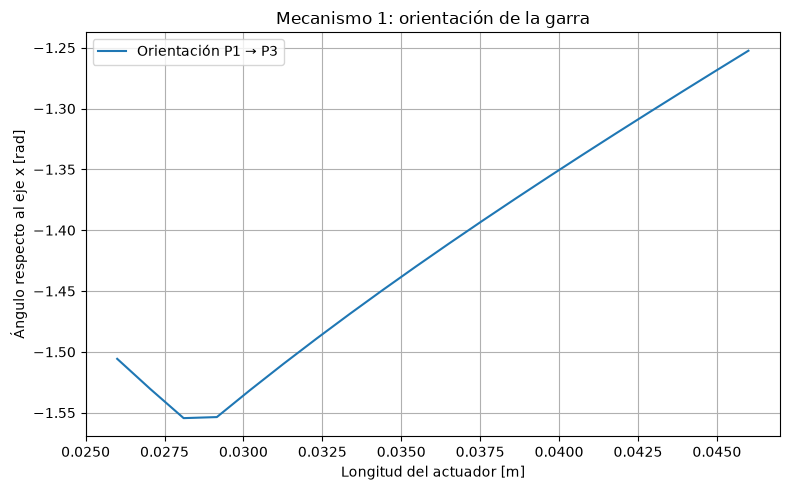

In [13]:
# MECANISMO 1 PUNTO C

fig, ejes = plt.subplots(1, 2, figsize=(12, 5))

for numero in range(3):

    ejes[0].plot(
        valores_de_actuador,
        [x1, x2, x3][numero],
        label=f"P{numero + 1}"
    )

    ejes[1].plot(
        valores_de_actuador,
        [y1, y2, y3][numero],
        label=f"P{numero + 1}"
    )

ejes[0].set_title("Mecanismo 1: posición x")
ejes[0].set_ylabel("Posición x [m]")

ejes[1].set_title("Mecanismo 1: posición y")
ejes[1].set_ylabel("Posición y [m]")

for eje in ejes:
    eje.set_xlabel("Longitud del actuador [m]")
    eje.grid(True)
    eje.legend()

plt.tight_layout()
plt.show()

# MECANISMO 1 PUNTO D

deltax1 = np.asarray(x3) - np.asarray(x1)
deltay1 = np.asarray(y3) - np.asarray(y1)

angulo1 = np.arctan2(deltay1, deltax1)

plt.figure(figsize=(8, 5))

plt.plot(
    valores_de_actuador,
    angulo1,
    label="Orientación P1 → P3"
)

plt.xlabel("Longitud del actuador [m]")
plt.ylabel("Ángulo respecto al eje x [rad]")
plt.title("Mecanismo 1: orientación de la garra")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

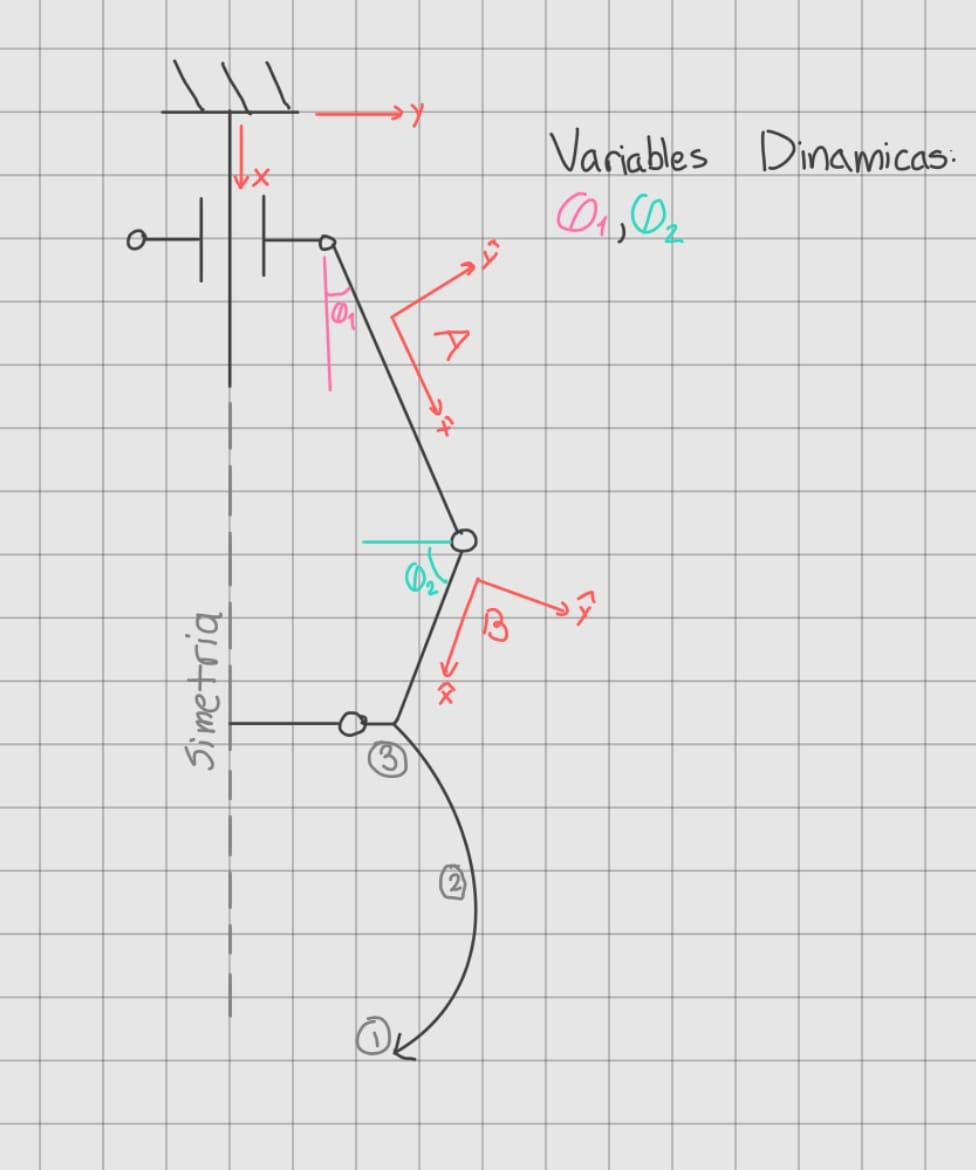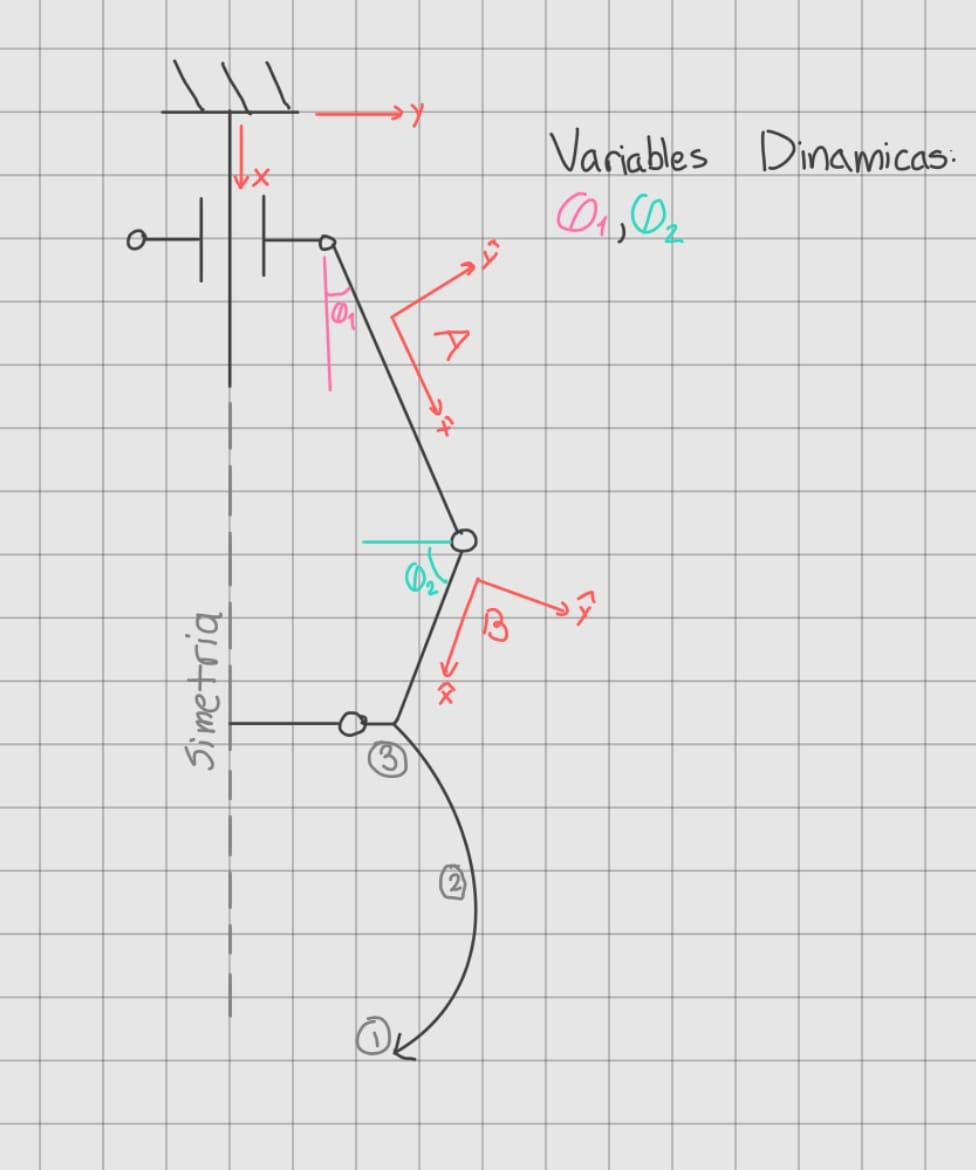

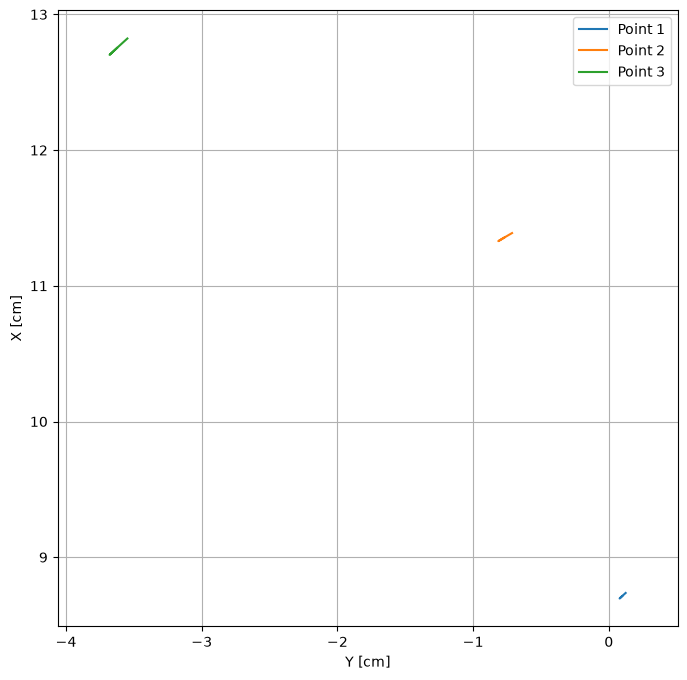

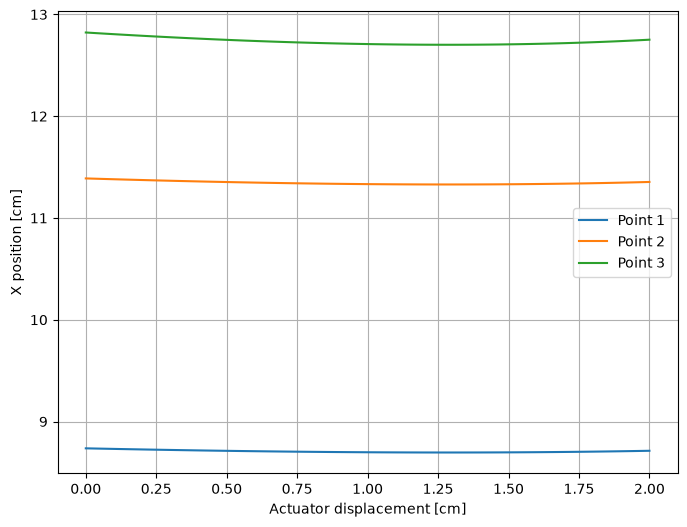

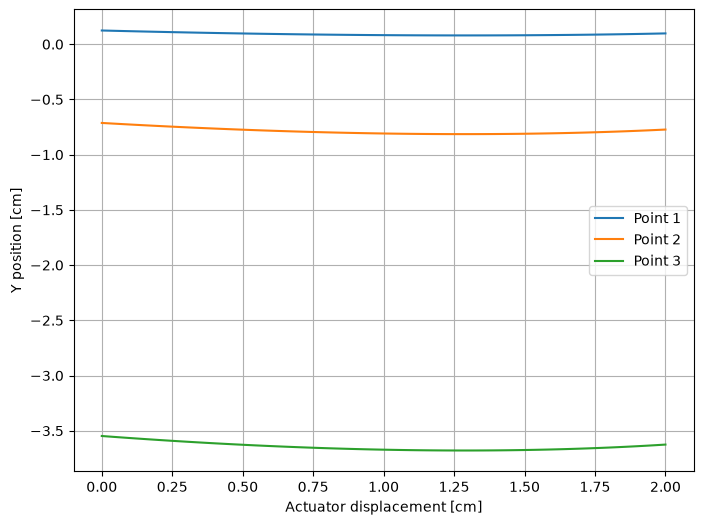

In [7]:
#MECANISMO 2
theta1, theta2, x = dynamicsymbols('theta1 theta2 x')
l1, l2, l3 = symbols('l1 l2 l3')

#lengths
L1 = 9.492 / 10
L2 = np.sqrt(56.19**2 + 23.24**2) / 10
L3 = np.sqrt(44.44**2 + 58.36**2) / 10

#reference frame
N = ReferenceFrame('N')
A = N.orientnew('A','Axis',(theta1, N.z))
B = N.orientnew('B','Axis',(theta2 - sp.pi / 2, N.z))

#vectores 
r1 = x * N.x + l1 * N.y
r2 = l2 * A.x
r3 = l3 * B.x
r4 = (-6.637) * N.x - 2.011 * N.y

#loop
ROC = r1 + r2 + r3 + r4

#Equations
eq_x = sp.simplify(ROC.dot(N.x))
eq_y = sp.simplify(ROC.dot(N.y))

#pasar a python functions
f_x = sp.lambdify(
    (theta1, theta2, x, l1, l2, l3),
    eq_x,
    'numpy'
)

f_y = sp.lambdify(
    (theta1, theta2, x, l1, l2, l3),
    eq_y,
    'numpy'
)

#resolver angles:
def find_angles(x_value, guess):

    def equations(q):

        t1, t2 = q

        return [
            f_x(t1, t2, x_value, L1, L2, L3),
            f_y(t1, t2, x_value, L1, L2, L3)
        ]

    sol = root(equations, guess)

    if not sol.success:
        return None

    return sol.x

# desplazamiento actaudor
x_values = np.linspace(0, 2, 100)

theta1_values = []
theta2_values = []

guess = [np.deg2rad(80), np.deg2rad(50)]

for x_value in x_values:

    solution = find_angles(x_value, guess)

    if solution is not None:
        theta1_values.append(solution[0])
        theta2_values.append(solution[1])

        # Use the previous solution as the next initial guess
        guess = solution

theta1 = np.rad2deg(theta1_values)
theta2 = np.rad2deg(theta2_values)

theta1_rad = np.array(theta1_values)
theta2_rad = np.array(theta2_values)

# r2 components
r2_x = L2 * np.cos(theta1_rad)
r2_y = L2 * np.sin(theta1_rad)

# r3 angle in the global reference frame
r3_angle = theta2_rad - np.pi / 2
delta_theta = r3_angle

# r3 components
r3_x = L3 * np.cos(r3_angle)
r3_y = L3 * np.sin(r3_angle)

# Endpoint of r3
end_r3_x = x_values + r2_x + r3_x
end_r3_y = L1 + r2_y + r3_y

# points of interest 

l31 = 2.823
l32 = 5.355
l322 = 1.15
l33 = 8.316

# Point 1
P1_dx = l31 * np.cos(delta_theta)
P1_dy = l31 * np.sin(delta_theta)

P1_x = end_r3_x + P1_dx
P1_y = end_r3_y + P1_dy


# Point 2
P2_dx = l32 * np.cos(delta_theta) - l322 * np.sin(delta_theta)
P2_dy = l32 * np.sin(delta_theta) + l322 * np.cos(delta_theta)

P2_x = end_r3_x + P2_dx
P2_y = end_r3_y + P2_dy


# Point 3
P3_dx = l33 * np.cos(delta_theta)
P3_dy = l33 * np.sin(delta_theta)

P3_x = end_r3_x + P3_dx
P3_y = end_r3_y + P3_dy

#Graph 1
plt.figure(figsize=(8, 8))

plt.plot(P1_y, P1_x, label='Point 1')
plt.plot(P2_y, P2_x, label='Point 2')
plt.plot(P3_y, P3_x, label='Point 3')

plt.xlabel('Y [cm]')
plt.ylabel('X [cm]')

plt.axis('equal')
plt.grid(True)
plt.legend()

plt.show()

#Graph 2
plt.figure(figsize=(8, 6))

plt.plot(x_values, P1_x, label='Point 1')
plt.plot(x_values, P2_x, label='Point 2')
plt.plot(x_values, P3_x, label='Point 3')

plt.xlabel('Actuator displacement [cm]')
plt.ylabel('X position [cm]')
plt.grid(True)
plt.legend()
plt.show()

#graph 3

plt.figure(figsize=(8, 6))

plt.plot(x_values, P1_y, label='Point 1')
plt.plot(x_values, P2_y, label='Point 2')
plt.plot(x_values, P3_y, label='Point 3')

plt.xlabel('Actuator displacement [cm]')
plt.ylabel('Y position [cm]')
plt.grid(True)
plt.legend()
plt.show()

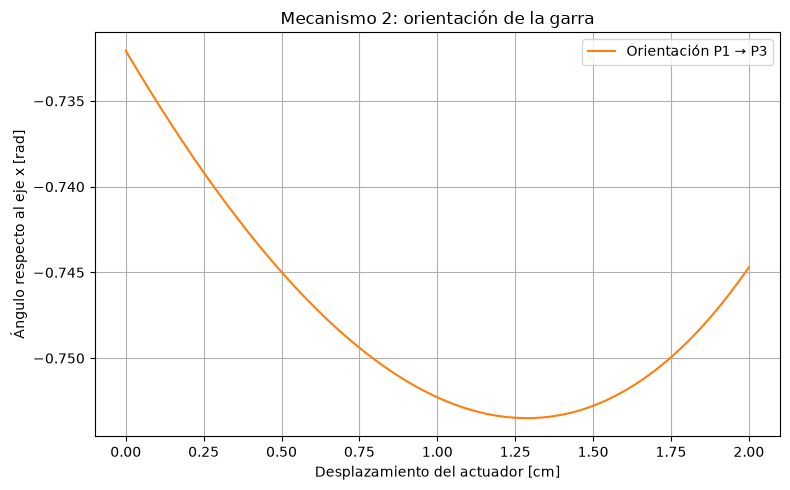

In [16]:
# MECANISMO 2 PUNTO D

deltax2 = np.asarray(P3_x) - np.asarray(P1_x)
deltay2 = np.asarray(P3_y) - np.asarray(P1_y)

angulo2 = np.arctan2(deltay2, deltax2)

plt.figure(figsize=(8, 5))

plt.plot(
    x_values,
    angulo2,
    color="tab:orange",
    label="Orientación P1 → P3"
)

plt.xlabel("Desplazamiento del actuador [cm]")
plt.ylabel("Ángulo respecto al eje x [rad]")
plt.title("Mecanismo 2: orientación de la garra")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

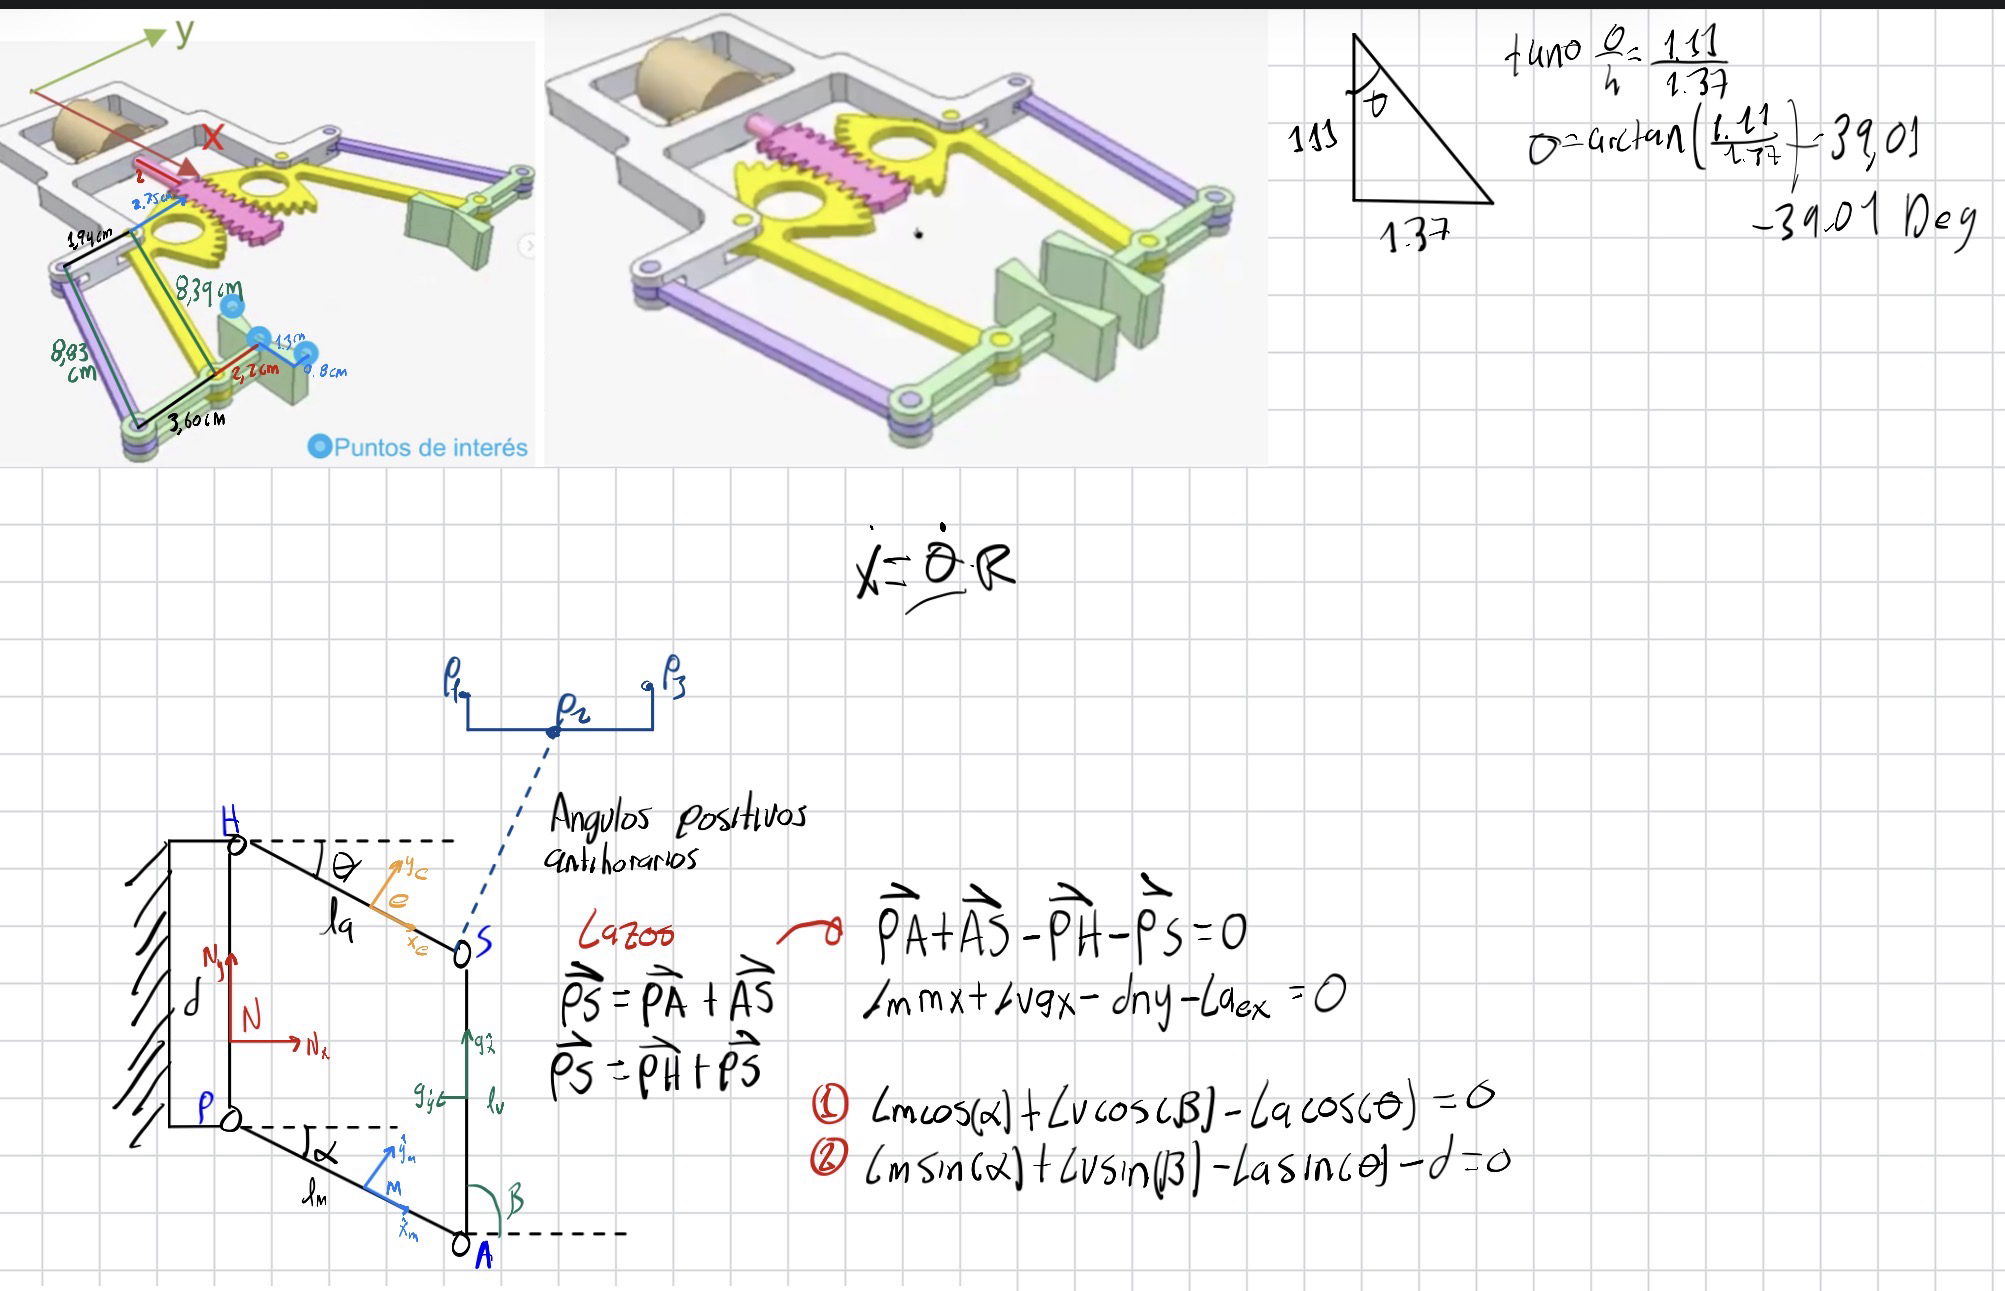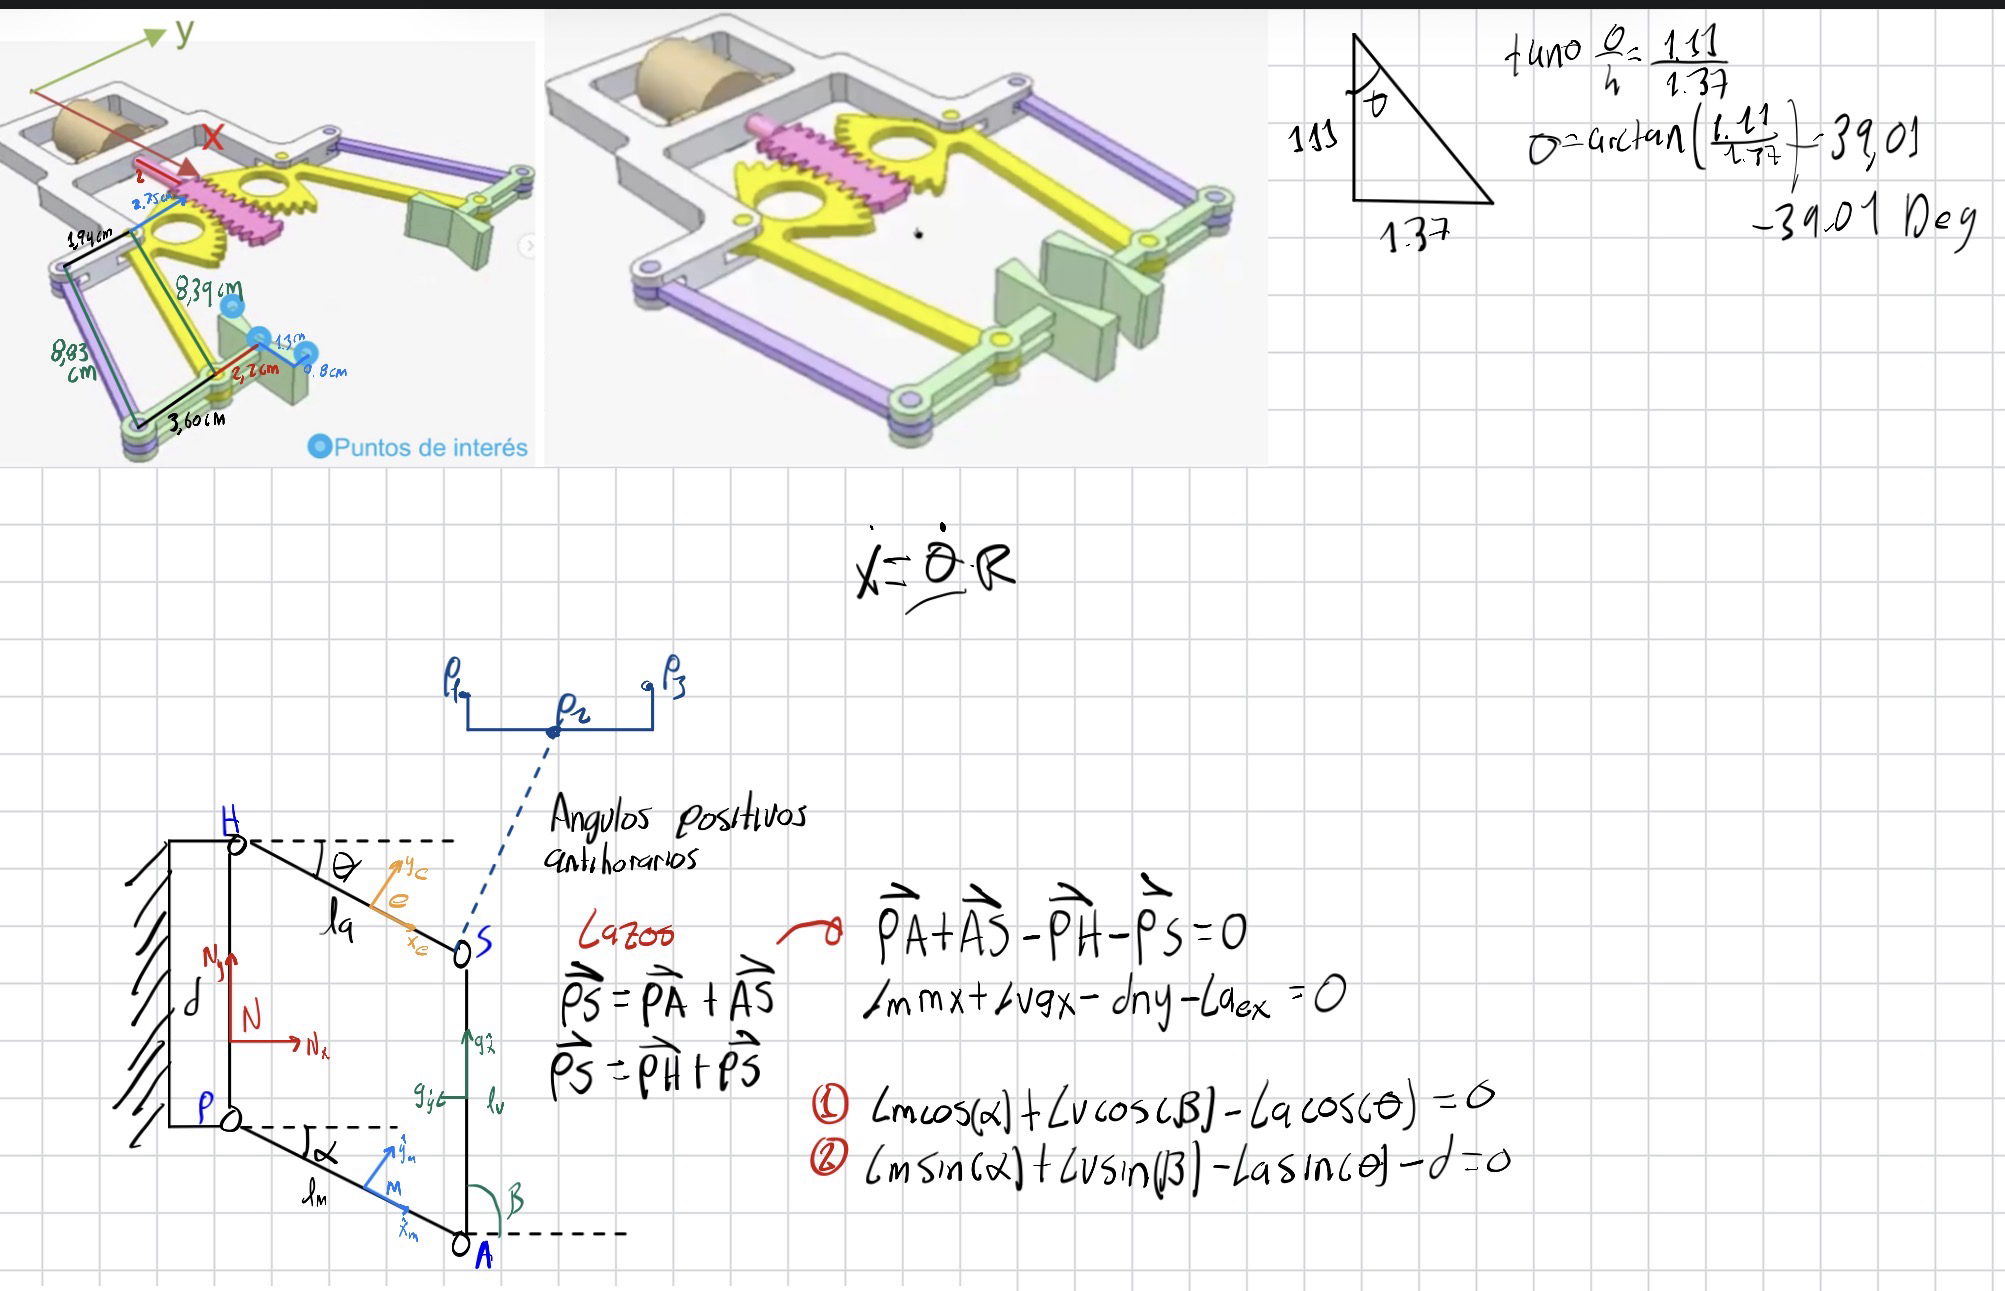

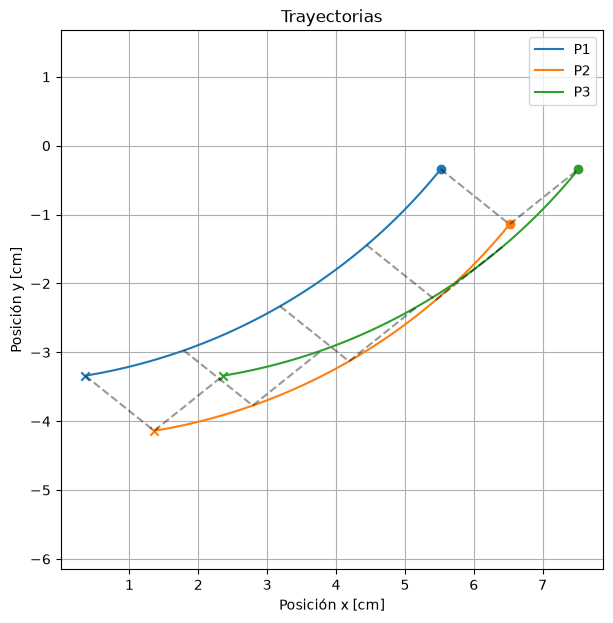

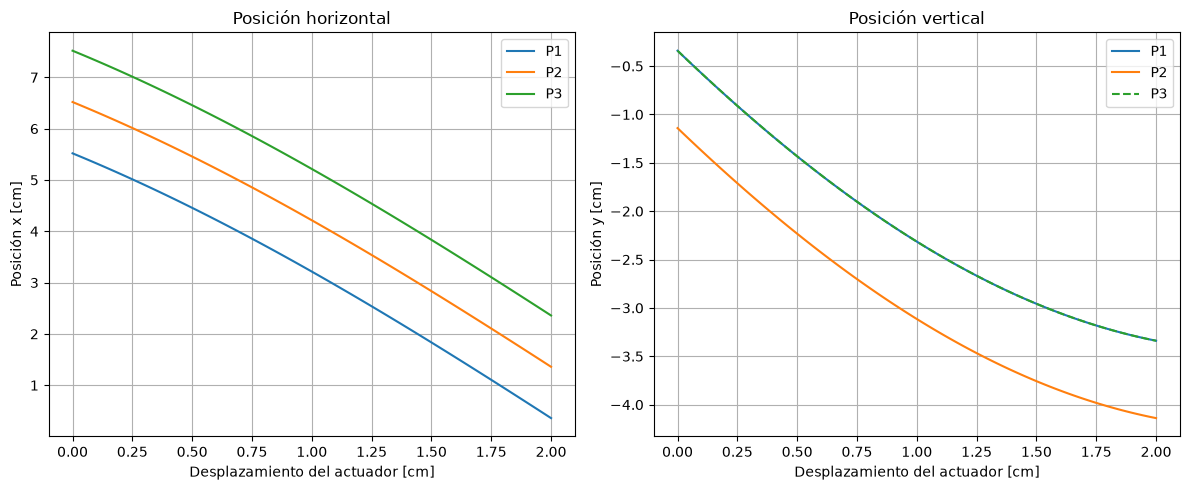

In [11]:
#MECANISMO 3
theta,alpha,beta = dynamicsymbols("theta alpha beta")
thetadot = theta.diff()
alphadot = alpha.diff()
betadot = beta.diff()
d,lm,la,lv = symbols("d lm la lv")

#Sistemas de referencia 
N = ReferenceFrame("N")
M = N.orientnew("M","Axis",(alpha,N.z))
E = N.orientnew("E","Axis",(theta,N.z)) 
G = N.orientnew("G","Axis",(beta,N.z))

r_PA = lm*M.x
r_AS = lv*G.x
r_PH = d*N.y
r_HS = la*E.x


loop = r_PA + r_AS - r_PH - r_HS

eq_x = loop.dot(N.x)
eq_y = loop.dot(N.y)
eqlist =[eq_x,eq_y]
# Dimensiones del paralelogramo con theta y alpha iguales
params = {
    d:  0.0194,
    lm: 0.0839,
    la: 0.0839,
    lv: 0.0194
}

# Posición de S respecto a P
r_PS = r_PH + r_HS

# Distancia desde S hasta P2
l_punta_x = 0.022

# Separación lateral entre los extremos
ancho_punta = 0.020
l_punta_y = ancho_punta / 2

# Cuánto sobresalen P1 y P3 respecto a P2 en dirección G.x
h = 0.008  

r_PP2 = r_PS + l_punta_x*G.x

r_PP1 = r_PP2 + h*G.x + l_punta_y*G.y
r_PP3 = r_PP2 + h*G.x - l_punta_y*G.y


condiciones = {
    alpha: theta,
    beta: sp.pi/2
}

puntos = {
    "P1": r_PP1,
    "P2": r_PP2,
    "P3": r_PP3
}
# Las posiciones ahora dependen únicamente de theta
points_func = {}

for nombre, vector in puntos.items():

    coordenada_x = vector.dot(N.x).subs(params).subs(condiciones)
    coordenada_y = vector.dot(N.y).subs(params).subs(condiciones)

    points_func[nombre] = sp.lambdify(theta,[coordenada_x, coordenada_y],"numpy")

# Recorrido del actuador
R = 0.0275
x_act = np.linspace(0, 0.020, 100)

theta0 = np.deg2rad(-39.01)
sentido = -1

trayectorias = {
    "P1": [],
    "P2": [],
    "P3": []
}

for x in x_act:

    theta_val = theta0 + sentido*x/R

    for nombre, funcion in points_func.items():
        posicion = funcion(theta_val)
        trayectorias[nombre].append(posicion)

# Gráfica de trayectorias
plt.figure(figsize=(7, 7))

for nombre in ["P1", "P2", "P3"]:

    trayectoria = np.array(trayectorias[nombre])

    linea, = plt.plot(
        trayectoria[:, 0]*100,
        trayectoria[:, 1]*100,
        label=nombre
    )

    # Inicio: círculo
    plt.scatter(
        trayectoria[0, 0]*100,
        trayectoria[0, 1]*100,
        color=linea.get_color(),
        marker="o"
    )

    # Final: equis
    plt.scatter(
        trayectoria[-1, 0]*100,
        trayectoria[-1, 1]*100,
        color=linea.get_color(),
        marker="x"
    )

plt.xlabel("Posición x [cm]")
plt.ylabel("Posición y [cm]")
plt.title("Trayectorias")
plt.axis("equal")
plt.grid()
plt.legend()
for i in [0, 25, 50, 75, 99]:

    posiciones = np.array([
        trayectorias["P1"][i],
        trayectorias["P2"][i],
        trayectorias["P3"][i]
    ])

    plt.plot(
        posiciones[:, 0]*100,
        posiciones[:, 1]*100,
        "k--",
        alpha=0.4
    )
plt.show()



# Posiciones en función del desplazamiento del actuador
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for nombre in ["P1", "P2", "P3"]:

    trayectoria = np.array(trayectorias[nombre])

    # Posición x vs. desplazamiento del actuador
    ax[0].plot(
        x_act * 100,
        trayectoria[:, 0] * 100,
        label=nombre
    )

    # Posición y vs. desplazamiento del actuador
    ax[1].plot(
        x_act * 100,
        trayectoria[:, 1] * 100,
        label=nombre,
        linestyle="--" if nombre == "P3" else "-"
    )

ax[0].set_xlabel("Desplazamiento del actuador [cm]")
ax[0].set_ylabel("Posición x [cm]")
ax[0].set_title("Posición horizontal")

ax[1].set_xlabel("Desplazamiento del actuador [cm]")
ax[1].set_ylabel("Posición y [cm]")
ax[1].set_title("Posición vertical")

for eje in ax:
    eje.grid()
    eje.legend()

plt.tight_layout()
plt.show()

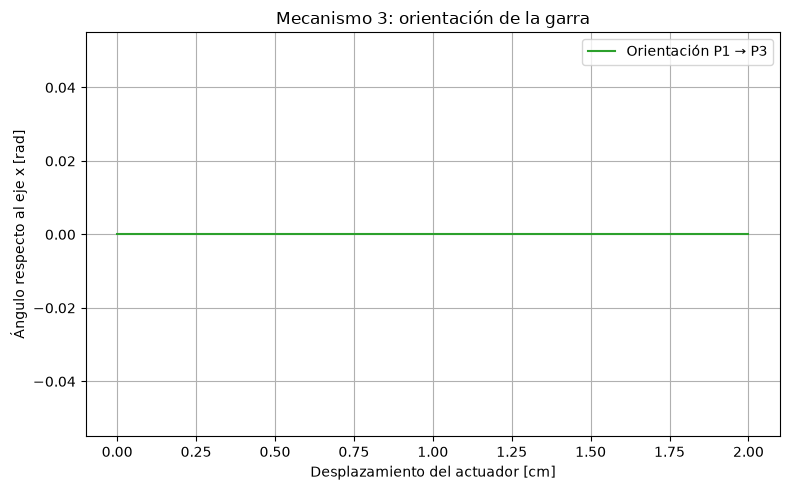

In [15]:
# MECANISMO 3 PUNTO D

punto1 = np.asarray(trayectorias["P1"])
punto3 = np.asarray(trayectorias["P3"])

deltax3 = punto3[:, 0] - punto1[:, 0]
deltay3 = punto3[:, 1] - punto1[:, 1]

angulo3 = np.arctan2(deltay3, deltax3)

plt.figure(figsize=(8, 5))

plt.plot(
    x_act * 100,
    angulo3,
    color="tab:green",
    label="Orientación P1 → P3"
)

plt.xlabel("Desplazamiento del actuador [cm]")
plt.ylabel("Ángulo respecto al eje x [rad]")
plt.title("Mecanismo 3: orientación de la garra")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Punto 2
Al comparar las gráficas, el mecanismo 1 presenta el mayor cambio de orientación de la garra, aproximadamente 0,30 rad, mientras que el mecanismo 2 muestra una variación menor, cercana a 0,02 rad. Ambos combinan desplazamiento y rotación. En cambio, el mecanismo 3 mantiene constante la orientación: sus tres puntos experimentan el mismo desplazamiento y la garra se traslada siguiendo trayectorias curvas sin girar.

El mecanismo 3 resulta el más adecuado para un agarre que requiera mantener paralelas las superficies de contacto, porque conserva la orientación durante todo el recorrido. Esto facilita la aproximación a objetos de caras planas sin cambiar la inclinación de las puntas. El mecanismo 1 sería útil cuando se necesita variar esa inclinación, mientras que la geometría curva del mecanismo 2 puede favorecer el contacto con objetos redondeados. Por tanto, considerando como criterio principal la conservación de la orientación durante el cierre, se selecciona el mecanismo 3.